# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.analysis.profit as profit_analysis

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality_parameters = (
    assumptions_module.load_mortality_parameters(
        "../data/mortality_parameters/smoker_multipliers.csv"
    )
)

base_mortality = assumptions_module.load_mortality_table(
    "../data/mortality_tables/ons_mortality.csv"
)

mortality = assumptions_module.MortalityTable(
    mortality_rates=base_mortality.mortality_rates,
    mortality_parameters=mortality_parameters
)

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Single Policy Setup

In [14]:
policy = policy_module.Policy(
    age=30,
    term=20,
    sum_assured=100000,
    premium=5000,
    gender="F",
    smoker_status="Smoker",
    product_type="Term"
)

# Projection Analysis

In [15]:
projection = projection_module.project_cashflows(
    policy,
    assumptions
)

projection

projection.rows[5]

ProjectionRow(t=5, age=35, prob_inforce=0.670431, qx=0.001099)

# Run valuation

In [16]:
valuation_result = valuation_module.value_policy(
    policy,
    assumptions,
    return_breakdown=True
)

# Core results

In [17]:
summary = {
    "PV Premiums": valuation_result.pv_premiums,
    "PV Claims": valuation_result.pv_claims,
    "Net Value": valuation_result.net_value
}

pd.Series(summary)

PV Premiums    47138.047585
PV Claims       1334.315557
Net Value      45803.732028
dtype: float64

# Build Analysis Dataset

In [18]:
df = profit_analysis.build_profit_dataframe(valuation_result)
df = profit_analysis.add_profit_signature(df)

# Profit Emergence Table

In [19]:
df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"
]].round(2)

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,4935.08,4935.08,4935.08,4935.08
1,1,4434.90,9369.98,4305.73,9240.80
2,2,4112.49,13482.46,3876.41,13117.22
3,3,3816.72,17299.19,3492.84,16610.06
4,4,3543.77,20842.95,3148.59,19758.65
5,5,3278.47,24121.43,2828.04,22586.69
6,6,3109.95,27231.37,2604.53,25191.22
7,7,2942.53,30173.90,2392.55,27583.77
8,8,2784.40,32958.30,2198.03,29781.80
9,9,2630.30,35588.60,2015.90,31797.70


# Profit Signature

In [20]:
df[["t", "pv_net", "profit_pct"]].round(4)

,t,pv_net,profit_pct
0,0,4935.0750,0.1077
1,1,4305.7290,0.0940
2,2,3876.4123,0.0846
3,3,3492.8428,0.0763
4,4,3148.5919,0.0687
5,5,2828.0411,0.0617
6,6,2604.5308,0.0569
7,7,2392.5467,0.0522
8,8,2198.0276,0.0480
9,9,2015.9041,0.0440


# Summary Metrics

In [21]:
pd.Series(profit_analysis.summary_metrics(df))

total_pv_profit      45803.732028
total_cash_profit    56819.269385
peak_profit_year         0.000000
dtype: float64

# Visualisations

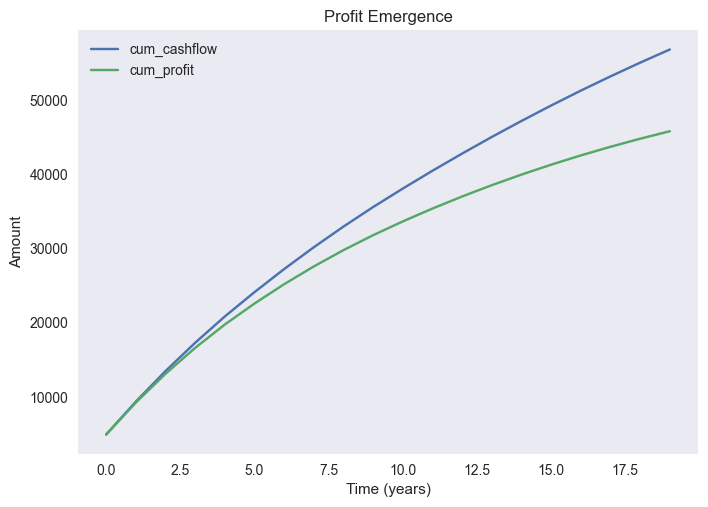

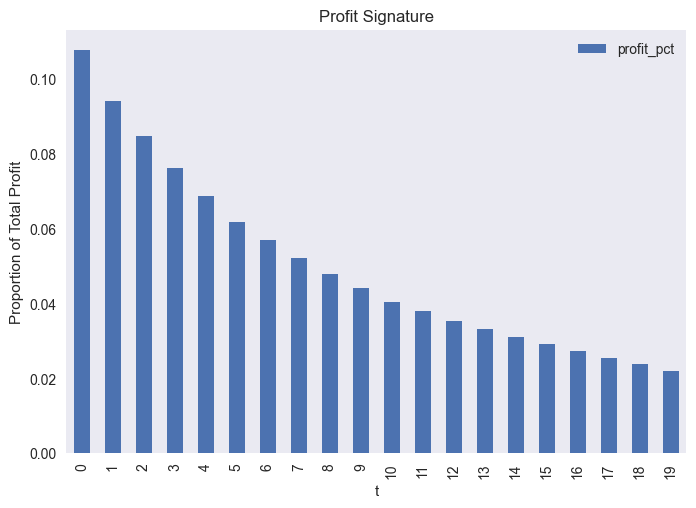

In [22]:
# Profit Emergence

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

df.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()